In [1]:
import yfinance as yf

tickers = ["ICLN","TAN","FAN","LIT","QCLN","SPY","QQQ", "TLT"]

data = yf.download(
    tickers,
    start="2010-01-01",
    auto_adjust=True,
    progress=False,
    threads=False
)

prices = data["Close"]

In [2]:
import pandas as pd
import numpy as np

In [3]:
returns = prices.pct_change().dropna()
print(prices.head())
print(prices.tail())
print(prices.columns)

Ticker            FAN       ICLN  LIT       QCLN        QQQ        SPY  \
Date                                                                     
2010-01-04  11.164366  16.120316  NaN  14.844875  40.290779  84.796379   
2010-01-05  11.222782  16.551792  NaN  15.071859  40.290779  85.020821   
2010-01-06  11.244687  16.693260  NaN  15.153575  40.047749  85.080711   
2010-01-07  11.310399  16.728636  NaN  15.153575  40.073799  85.439819   
2010-01-08  11.514851  16.877169  NaN  15.117254  40.403610  85.724174   

Ticker            TAN        TLT  
Date                              
2010-01-04  78.315544  56.135197  
2010-01-05  81.643402  56.497681  
2010-01-06  81.569450  55.741386  
2010-01-07  81.939217  55.835136  
2010-01-08  83.418251  55.810150  
Ticker            FAN       ICLN        LIT       QCLN         QQQ  \
Date                                                                 
2026-04-24  26.290001  19.990000  83.790001  56.970001  663.880005   
2026-04-27  26.600000  20.

In [4]:
prices_monthly = prices.resample("M").last()

# Drop months where any ETF is missing
prices_monthly = prices_monthly.dropna()

returns = prices_monthly.pct_change().dropna()

print(prices_monthly.head())
print(returns.head())
print(returns.describe())

Ticker           FAN       ICLN        LIT       QCLN        QQQ        SPY  \
Date                                                                          
2010-07-31  8.034328  11.604752  27.410212  13.492033  39.957634  83.240723   
2010-08-31  7.106441  11.090572  26.489412  12.220916  37.907841  79.496544   
2010-09-30  7.540929  12.333178  30.567234  13.855208  42.901386  86.615799   
2010-10-31  7.710303  12.111791  32.704803  14.127596  45.620419  89.924713   
2010-11-30  6.900245  10.619244  33.313190  14.300103  45.541733  89.924713   

Ticker            TAN        TLT  
Date                              
2010-07-31  56.351685  64.094101  
2010-08-31  53.911274  69.472084  
2010-09-30  63.672974  67.721199  
2010-10-31  62.193928  64.694519  
2010-11-30  50.657364  63.601662  
Ticker           FAN      ICLN       LIT      QCLN       QQQ       SPY  \
Date                                                                     
2010-08-31 -0.115490 -0.044308 -0.033593 -0.094212 -0

/tmp/ipykernel_17944/518190972.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prices_monthly = prices.resample("M").last()


In [5]:
core = ["ICLN", "TAN", "FAN", "LIT", "QCLN"]
hedge = ["SPY", "QQQ", "TLT"]
assets = core + hedge
#we'll use both the core and hedge assets in the optimization
#the equally weighted alternative energy ETFs is the 'benchmark'
#the active portfolio is the portfolio with the tilts and the hedge
#they should all go into the same return vector and covariance matrix (for the active portfolio)
#the core assets define the theme, the hedge ETFs will not tilt up/down, they're pure active positions
#hedge assets only appear if the optimizer chooses them

prices = prices[assets]

In [6]:
returns = prices.pct_change().dropna()

rf = 0

# Excess returns
excess_returns = returns - rf

In [7]:
benchmark_weights = np.array([1/len(core)] * len(core))

benchmark_returns = excess_returns[core].dot(benchmark_weights)

In [8]:
X = excess_returns.copy()

In [67]:
from scipy.optimize import minimize
import numpy as np

def optimize_active(mu, Sigma, gamma=1, bounds_type="basic"):
    n = len(mu)

    # stabilize covariance matrix
    Sigma = Sigma + 1e-5 * np.eye(n)

    def objective(x):
        return -(x @ mu - 0.5 * gamma * x @ Sigma @ x)

    constraints = ({
        "type": "eq",
        "fun": lambda x: np.sum(x)
    })

    bounds = get_bounds(bounds_type, assets, core, hedge)

    x0 = np.zeros(n)

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        return result.x

    print("Optimization failed:", result.message)
    return np.zeros(n)

In [68]:
test_mu = np.ones(len(returns.columns)) * 0.01
test_Sigma = np.eye(len(returns.columns))

test_x = optimize_active(test_mu, test_Sigma, gamma=1, bounds_type="basic")
print(test_x)

[0. 0. 0. 0. 0. 0. 0. 0.]


In [51]:
def get_portfolio_weights(active_weights, benchmark_weights, core_len):
    if active_weights is None:
        print("Warning: active_weights was None; using zero active tilt.")
        active_weights = np.zeros(len(returns.columns))

    w = np.zeros(len(active_weights))

    # benchmark weights for core assets
    w[:core_len] = benchmark_weights + active_weights[:core_len]

    # hedge assets only come from active positions
    w[core_len:] = active_weights[core_len:]

    return w

In [52]:
# #another version including TLT for an interest rate hedge
# #shorting TLT if interest rates rise, long to hedge rate shocks
# #lets only use this version if it provides better results

# core = ["ICLN", "TAN", "FAN", "LIT", "QCLN"]
# hedge = ["SPY", "QQQ", "TLT"]   # ← added TLT
# assets = core + hedge

In [53]:
import yfinance as yf

prices = yf.download(
    assets,
    start="2010-01-01",
    auto_adjust=True,
    progress=False,
    threads=False
)["Close"]

In [54]:
prices = prices[assets]

prices_monthly = prices.resample("M").last()

# Dropping rows where any asset is missing
prices_monthly = prices_monthly.dropna()

/tmp/ipykernel_17944/3190986272.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prices_monthly = prices.resample("M").last()


In [55]:
returns = prices_monthly.pct_change().dropna()

In [56]:
benchmark_weights = np.array([1/len(core)] * len(core))
benchmark_returns = returns[core].dot(benchmark_weights)

In [57]:
X = returns.copy()

In [58]:
print(returns.columns)
print(returns.describe())

Index(['ICLN', 'TAN', 'FAN', 'LIT', 'QCLN', 'SPY', 'QQQ', 'TLT'], dtype='object', name='Ticker')
Ticker        ICLN         TAN         FAN         LIT        QCLN  \
count   189.000000  189.000000  189.000000  189.000000  189.000000   
mean      0.006157    0.006882    0.008233    0.009484    0.011746   
std       0.077978    0.115299    0.060405    0.081415    0.089861   
min      -0.298790   -0.408425   -0.155367   -0.247768   -0.232741   
25%      -0.043621   -0.075320   -0.031473   -0.037854   -0.042955   
50%       0.006185    0.000000    0.011034    0.003475    0.012677   
75%       0.054907    0.083591    0.042351    0.059622    0.067982   
max       0.202965    0.273750    0.153579    0.210758    0.337906   

Ticker         SPY         QQQ         TLT  
count   189.000000  189.000000  189.000000  
mean      0.012310    0.016247    0.002306  
std       0.041205    0.050145    0.039439  
min      -0.124871   -0.135957   -0.094239  
25%      -0.011214   -0.015654   -0.025203  
50

Let's run the optimizer first and then adjust accordingly. We want to make sure the original basket weights are > 0, but the other 3 ETFs can be shorted if that's what the optimizer chooses. If the weights come out with extreme tilting, we can introduce weight caps (maybe 30%). We could also add a minimum allocation to the basket ETFs if their weights are tiny from the optimizer.

In [59]:
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

In [60]:
def get_portfolio_weights(active_weights, benchmark_weights, core_len):
    w = np.zeros(len(active_weights))
    w[:core_len] = benchmark_weights + active_weights[:core_len]
    w[core_len:] = active_weights[core_len:]
    return w

In [61]:
def optimize_active(mu, Sigma, gamma=5, bounds_type="basic"):
    n = len(mu)

    def objective(x):
        return -(x @ mu - 0.5 * gamma * x @ Sigma @ x)

    constraints = [
        {
            "type": "eq",
            "fun": lambda x: np.sum(x)
        }
    ]

def get_bounds(bounds_type, assets, core, hedge):
    bounds = []

    for a in assets:
        if bounds_type == "basic":
            bounds.append((-0.50, 0.50))

        elif bounds_type == "constrained":
            if a in core:
                bounds.append((-0.15, 0.15))
            else:
                bounds.append((-0.15, 0.15))

        elif bounds_type == "hedge_short_only":
            if a in core:
                bounds.append((-0.15, 0.15))
            else:
                bounds.append((-0.15, 0.00))

        elif bounds_type == "core_only":
            if a in core:
                bounds.append((-0.15, 0.15))
            else:
                bounds.append((0.00, 0.00))

    return bounds

    x0 = np.zeros(n)

    result = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return result.x

In [62]:
def weights_summary(weights):
    return pd.DataFrame({
        "Average Weight (%)": (weights.mean() * 100).round(2),
        "Min Weight (%)": (weights.min() * 100).round(2),
        "Max Weight (%)": (weights.max() * 100).round(2)
    })

In [175]:
def run_backtest(bounds_type="basic", mu_method="sample", sigma_method="sample", rebalance_step=1):
    window = 36
    gamma = 5

    asset_cols_clean = ["ICLN", "TAN", "FAN", "LIT", "QCLN", "SPY", "QQQ", "TLT"]
    returns_opt = returns[asset_cols_clean].copy()

    portfolio_returns = []
    benchmark_oos = []
    weights_history = []

    core_len = len(core)
    benchmark_weights = np.repeat(1 / core_len, core_len)

    current_w = None

    for t in range(window, len(returns_opt) - 1):

        if current_w is None or (t - window) % rebalance_step == 0:
            train = returns_opt.iloc[t-window:t]

            # if mu_method == "sample":
            #     mu = train.mean().values
            # elif mu_method == "shrink":
            #     mu = 0.5 * train.mean().values
            # if mu_method == "sample":
            #     mu = train.mean().values

            # elif mu_method == "shrink":
            #     mu = 0.5 * train.mean().values

            # elif mu_method == "strong_shrink":
            #     mu = 0.25 * train.mean().values

            #testing factor model
            if mu_method == "sample":
                mu = train.mean().values

            elif mu_method == "shrink":
                mu = 0.5 * train.mean().values

            elif mu_method == "strong_shrink":
                mu = 0.25 * train.mean().values

            elif mu_method == "factor":
            # simple factor proxy model using SPY, QQQ, TLT, and WTI (oil price returns as an indicator)
                factor_cols = ["SPY", "QQQ", "TLT", "WTI"]
                asset_cols = train.columns.tolist()

                F = train[factor_cols].values
                F = np.column_stack([np.ones(len(F)), F])  # add intercept

                mu_factor = []

                for asset in asset_cols:
                    y = train[asset].values

                    beta = np.linalg.lstsq(F, y, rcond=None)[0]

                    expected_factors = 0.5 * train[factor_cols].mean().values
                    expected_x = np.r_[1, expected_factors]

                    pred_mu = expected_x @ beta
                    mu_factor.append(pred_mu)

                #mu = np.array(mu_factor)
                mu_sample = train.mean().values
                mu_factor = np.array(mu_factor)

                mu = 0.5 * mu_sample + 0.5 * mu_factor

    # shrink factor forecast to reduce noise
            #mu = 0.5 * mu
            else:
                raise ValueError(f"Unknown mu_method: {mu_method}")

            Sigma = LedoitWolf().fit(train.values).covariance_

            x = optimize_active(mu, Sigma, gamma=gamma, bounds_type=bounds_type)

            print("x:", x)

            if x is None:
                print(f"Optimization failed at t={t}")
                x = np.zeros(len(returns.columns))
            else:
                print("sum active:", np.sum(x))
                print("core active:", x[:core_len])
                print("hedge active:", x[core_len:])

        current_w = get_portfolio_weights(x, benchmark_weights, core_len)

        next_ret = returns_opt.iloc[t+1].values

        portfolio_returns.append(current_w @ next_ret)
        benchmark_oos.append(returns[core].iloc[t+1].mean())
        weights_history.append(current_w)

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=returns.index[window+1:],
        name="Optimized Portfolio"
    )

    benchmark_oos = pd.Series(
        benchmark_oos,
        index=returns.index[window+1:],
        name="Equal-Weight Benchmark"
    )

    weights_history = pd.DataFrame(
        weights_history,
        index=returns.index[window+1:],
        columns=assets
    )

    return portfolio_returns, benchmark_oos, weights_history

In [176]:
strong_shrink_returns, strong_shrink_bench, strong_shrink_weights = run_backtest(
    bounds_type="constrained",
    mu_method="strong_shrink",
    sigma_method="sample",
    rebalance_step=1
)

x: [-0.13671728 -0.01836649  0.05389813 -0.15        0.06575225  0.15
  0.15       -0.11456661]
sum active: 0.0
core active: [-0.13671728 -0.01836649  0.05389813 -0.15        0.06575225]
hedge active: [ 0.15        0.15       -0.11456661]
x: [-0.15        0.02287247  0.07646674 -0.15        0.0073939   0.15
  0.15       -0.10673311]
sum active: -5.551115123125783e-17
core active: [-0.15        0.02287247  0.07646674 -0.15        0.0073939 ]
hedge active: [ 0.15        0.15       -0.10673311]
x: [-0.14308886 -0.00059033  0.04963018 -0.15        0.04857309  0.15
  0.15       -0.10452408]
sum active: -2.7755575615628914e-17
core active: [-0.14308886 -0.00059033  0.04963018 -0.15        0.04857309]
hedge active: [ 0.15        0.15       -0.10452408]
x: [-0.15        0.01498703  0.03454336 -0.15        0.06510924  0.09716622
  0.14960765 -0.06141351]
sum active: 0.0
core active: [-0.15        0.01498703  0.03454336 -0.15        0.06510924]
hedge active: [ 0.09716622  0.14960765 -0.06141351]

In [177]:
def weights_summary(weights):
    return pd.DataFrame({
        "Average Weight (%)": (weights.mean() * 100).round(2),
        "Min Weight (%)": (weights.min() * 100).round(2),
        "Max Weight (%)": (weights.max() * 100).round(2)
    })

In [178]:
# performance_summary: shared metric helper used by the existing comparison tables.
# Annualization assumes monthly returns (12 periods/year). Sharpe here uses rf=0
# to stay consistent with the existing tables in cells below; the final analytics
# section at the bottom of the notebook re-runs everything with the real Ken-French
# risk-free rate and reports IR + FF6 alpha.

def performance_summary(returns, periods_per_year=12):
    name = returns.name if returns.name is not None else "Portfolio"
    ann_return = returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 0 else float("nan")
    cum = (1 + returns).cumprod()
    drawdown = (cum - cum.cummax()) / cum.cummax()
    max_dd = drawdown.min()
    return pd.DataFrame(
        {
            name: [
                round(ann_return, 6),
                round(ann_vol, 6),
                round(sharpe, 6),
                round(max_dd, 6),
            ]
        },
        index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Max Drawdown"],
    )


1. basic optimazation

In [179]:
baseline_returns, benchmark_oos, baseline_weights = run_backtest(
    bounds_type="basic",
    mu_method="sample",
    sigma_method="sample",
    rebalance_step=1
)

baseline_summary = pd.concat([
    performance_summary(baseline_returns),
    performance_summary(benchmark_oos)
], axis=1)

baseline_summary.columns = ["Basic Optimization", "Equal-Weight Benchmark"]
baseline_summary

x: [-0.5        -0.10868183  0.30051358 -0.5         0.21427072  0.5
  0.5        -0.40610247]
sum active: 0.0
core active: [-0.5        -0.10868183  0.30051358 -0.5         0.21427072]
hedge active: [ 0.5         0.5        -0.40610247]
x: [-0.5         0.04990762  0.39457336 -0.5        -0.06594947  0.5
  0.5        -0.37853151]
sum active: 0.0
core active: [-0.5         0.04990762  0.39457336 -0.5        -0.06594947]
hedge active: [ 0.5         0.5        -0.37853151]
x: [-0.5        -0.03102899  0.27080593 -0.5         0.12036919  0.5
  0.5        -0.36014613]
sum active: -1.1102230246251565e-16
core active: [-0.5        -0.03102899  0.27080593 -0.5         0.12036919]
hedge active: [ 0.5         0.5        -0.36014613]
x: [-0.5         0.04522376  0.0796922  -0.5         0.14038624  0.5
  0.5        -0.2653022 ]
sum active: 0.0
core active: [-0.5         0.04522376  0.0796922  -0.5         0.14038624]
hedge active: [ 0.5        0.5       -0.2653022]
x: [-0.5         0.08645707  0.

,Basic Optimization,Equal-Weight Benchmark
Annualized Return,0.105373,0.127020
Annualized Volatility,0.369246,0.255279
Sharpe Ratio,0.285373,0.497573
Max Drawdown,-0.740642,-0.547463


In [180]:
baseline_returns, benchmark_oos, baseline_weights = run_backtest(
    bounds_type="basic",
    mu_method="sample",
    sigma_method="sample",
    rebalance_step=1
)

x: [-0.5        -0.10868183  0.30051358 -0.5         0.21427072  0.5
  0.5        -0.40610247]
sum active: 0.0
core active: [-0.5        -0.10868183  0.30051358 -0.5         0.21427072]
hedge active: [ 0.5         0.5        -0.40610247]
x: [-0.5         0.04990762  0.39457336 -0.5        -0.06594947  0.5
  0.5        -0.37853151]
sum active: 0.0
core active: [-0.5         0.04990762  0.39457336 -0.5        -0.06594947]
hedge active: [ 0.5         0.5        -0.37853151]
x: [-0.5        -0.03102899  0.27080593 -0.5         0.12036919  0.5
  0.5        -0.36014613]
sum active: -1.1102230246251565e-16
core active: [-0.5        -0.03102899  0.27080593 -0.5         0.12036919]
hedge active: [ 0.5         0.5        -0.36014613]
x: [-0.5         0.04522376  0.0796922  -0.5         0.14038624  0.5
  0.5        -0.2653022 ]
sum active: 0.0
core active: [-0.5         0.04522376  0.0796922  -0.5         0.14038624]
hedge active: [ 0.5        0.5       -0.2653022]
x: [-0.5         0.08645707  0.

In [181]:
weights_summary(baseline_weights)

,Average Weight (%),Min Weight (%),Max Weight (%)
ICLN,-11.45,-30.00,70.00
TAN,28.73,-30.00,70.00
FAN,16.79,-30.00,70.00
LIT,12.40,-30.00,70.00
QCLN,26.14,-30.00,70.00
SPY,18.75,-50.00,50.00
QQQ,44.29,-16.21,50.00
TLT,-35.67,-50.00,21.18


The baseline optimization produces highly unstable and extreme portfolio weights.
In particular, several assets take very large long or short positions, indicating that the optimizer is overfitting to noisy return estimates.
As a result, the portfolio performs poorly out-of-sample compared to the equal-weight benchmark.

2. with constraints

In [132]:
constrained_returns, benchmark_oos, constrained_weights = run_backtest(
    bounds_type="constrained",
    mu_method="sample",
    sigma_method="sample",
    rebalance_step=1
)

constraint_summary = pd.concat([
    performance_summary(baseline_returns),
    performance_summary(constrained_returns),
    performance_summary(benchmark_oos)
], axis=1)

constraint_summary.columns = [
    "Basic Optimization",
    "Constrained Optimization",
    "Equal-Weight Benchmark"
]

constraint_summary

x: [-0.15       -0.15        0.05186492 -0.15        0.15        0.15
  0.15       -0.05186492]
sum active: -1.6653345369377348e-16
core active: [-0.15       -0.15        0.05186492 -0.15        0.15      ]
hedge active: [ 0.15        0.15       -0.05186492]
x: [-0.15 -0.15  0.15 -0.15  0.15  0.15  0.15 -0.15]
sum active: 0.0
core active: [-0.15 -0.15  0.15 -0.15  0.15]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15 -0.15  0.15 -0.15  0.15  0.15  0.15 -0.15]
sum active: 0.0
core active: [-0.15 -0.15  0.15 -0.15  0.15]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15 -0.15  0.15 -0.15  0.15  0.15  0.15 -0.15]
sum active: -5.551115123125783e-17
core active: [-0.15 -0.15  0.15 -0.15  0.15]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15       -0.11474941  0.15       -0.15        0.11474941  0.15
  0.15       -0.15      ]
sum active: -5.551115123125783e-17
core active: [-0.15       -0.11474941  0.15       -0.15        0.11474941]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15 -0.15  0.15 -0.15  0.15  0.1

,Basic Optimization,Constrained Optimization,Equal-Weight Benchmark
Annualized Return,0.118235,0.130553,0.140263
Annualized Volatility,0.366779,0.295458,0.256051
Sharpe Ratio,0.322361,0.441865,0.547791
Max Drawdown,-0.740642,-0.620925,-0.547463


In [116]:
weights_summary(constrained_weights)

,Average Weight (%),Min Weight (%),Max Weight (%)
ICLN,11.60,5.00,35.0
TAN,20.06,5.00,35.0
FAN,20.07,5.00,35.0
LIT,17.99,5.00,35.0
QCLN,24.77,5.00,35.0
SPY,4.88,-15.00,15.0
QQQ,12.16,-14.92,15.0
TLT,-11.53,-15.00,15.0


Introducing constraints significantly stabilizes the portfolio weights and prevents extreme allocations.
The core ETFs maintain positive exposure, and hedge positions are more controlled.
Although performance improves relative to the baseline, the constrained portfolio still underperforms the equal-weight benchmark.

3. adjust mu and sigma

In [133]:
mu_shrink_returns, benchmark_oos, mu_shrink_weights = run_backtest(
    bounds_type="constrained",
    mu_method="shrink",
    sigma_method="sample",
    rebalance_step=1
)

sigma_shrink_returns, benchmark_oos, sigma_shrink_weights = run_backtest(
    bounds_type="constrained",
    mu_method="sample",
    sigma_method="lw",
    rebalance_step=1
)

mu_sigma_shrink_returns, benchmark_oos, mu_sigma_shrink_weights = run_backtest(
    bounds_type="constrained",
    mu_method="shrink",
    sigma_method="lw",
    rebalance_step=1
)

input_summary = pd.concat([
    performance_summary(constrained_returns),
    performance_summary(mu_shrink_returns),
    performance_summary(sigma_shrink_returns),
    performance_summary(mu_sigma_shrink_returns),
    performance_summary(benchmark_oos)
], axis=1)

input_summary.columns = [
    "Sample Mu + Sample Sigma",
    "Shrink Mu + Sample Sigma",
    "Sample Mu + LW Sigma",
    "Shrink Mu + LW Sigma",
    "Equal-Weight Benchmark"
]

input_summary

x: [-0.15       -0.08084536 -0.00287294 -0.15        0.15        0.15
  0.15       -0.0662817 ]
sum active: 0.0
core active: [-0.15       -0.08084536 -0.00287294 -0.15        0.15      ]
hedge active: [ 0.15       0.15      -0.0662817]
x: [-0.15 -0.15  0.15 -0.15  0.15  0.15  0.15 -0.15]
sum active: 5.551115123125783e-17
core active: [-0.15 -0.15  0.15 -0.15  0.15]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15       -0.11553245  0.11553245 -0.15        0.15        0.15
  0.15       -0.15      ]
sum active: 1.1102230246251565e-16
core active: [-0.15       -0.11553245  0.11553245 -0.15        0.15      ]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15       -0.11085741  0.12700376 -0.15        0.13385365  0.15
  0.15       -0.15      ]
sum active: 0.0
core active: [-0.15       -0.11085741  0.12700376 -0.15        0.13385365]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15       -0.03406265  0.15       -0.15        0.02361801  0.15
  0.15       -0.13955536]
sum active: -2.7755575615628914e-17
core 

,Sample Mu + Sample Sigma,Shrink Mu + Sample Sigma,Sample Mu + LW Sigma,Shrink Mu + LW Sigma,Equal-Weight Benchmark
Annualized Return,0.130553,0.137129,0.130553,0.137129,0.140263
Annualized Volatility,0.295458,0.288460,0.295458,0.288460,0.256051
Sharpe Ratio,0.441865,0.475382,0.441865,0.475382,0.547791
Max Drawdown,-0.620925,-0.601961,-0.620925,-0.601961,-0.547463


In [134]:
weights_summary(mu_shrink_weights)

,Average Weight (%),Min Weight (%),Max Weight (%)
ICLN,10.46,5.00,35.00
TAN,21.29,5.00,35.00
FAN,19.71,5.00,35.00
LIT,17.83,5.00,35.00
QCLN,23.70,5.00,35.00
SPY,5.80,-15.00,15.00
QQQ,13.18,-2.18,15.00
TLT,-11.97,-15.00,9.17


We test alternative input estimation methods to reduce estimation error.
Shrinking expected returns improves performance, suggesting that return estimates are highly noisy.
In contrast, covariance shrinkage alone does not improve results, and may even worsen performance.
This indicates that estimation error in expected returns is the primary driver of instability in the optimization.

4.adjust frequency

In [94]:
monthly_returns, benchmark_oos, monthly_weights = run_backtest(
    bounds_type="constrained",
    mu_method="shrink",
    sigma_method="sample",
    rebalance_step=1
)

quarterly_returns, benchmark_oos, quarterly_weights = run_backtest(
    bounds_type="constrained",
    mu_method="shrink",
    sigma_method="sample",
    rebalance_step=3
)

semiannual_returns, benchmark_oos, semiannual_weights = run_backtest(
    bounds_type="constrained",
    mu_method="shrink",
    sigma_method="sample",
    rebalance_step=6
)

rebalance_summary = pd.concat([
    performance_summary(monthly_returns),
    performance_summary(quarterly_returns),
    performance_summary(semiannual_returns),
    performance_summary(benchmark_oos)
], axis=1)

rebalance_summary.columns = [
    "Monthly",
    "Quarterly",
    "Semiannual",
    "Equal-Weight Benchmark"
]

rebalance_summary

x: [-0.15       -0.08084536 -0.00287294 -0.15        0.15        0.15
  0.15       -0.0662817 ]
sum active: 0.0
core active: [-0.15       -0.08084536 -0.00287294 -0.15        0.15      ]
hedge active: [ 0.15       0.15      -0.0662817]
x: [-0.15 -0.15  0.15 -0.15  0.15  0.15  0.15 -0.15]
sum active: 5.551115123125783e-17
core active: [-0.15 -0.15  0.15 -0.15  0.15]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15       -0.11553245  0.11553245 -0.15        0.15        0.15
  0.15       -0.15      ]
sum active: 1.1102230246251565e-16
core active: [-0.15       -0.11553245  0.11553245 -0.15        0.15      ]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15       -0.11085741  0.12700376 -0.15        0.13385365  0.15
  0.15       -0.15      ]
sum active: 0.0
core active: [-0.15       -0.11085741  0.12700376 -0.15        0.13385365]
hedge active: [ 0.15  0.15 -0.15]
x: [-0.15       -0.03406265  0.15       -0.15        0.02361801  0.15
  0.15       -0.13955536]
sum active: -2.7755575615628914e-17
core 

,Monthly,Quarterly,Semiannual,Equal-Weight Benchmark
Annualized Return,0.137129,0.134236,0.132167,0.140263
Annualized Volatility,0.288460,0.289491,0.291919,0.256051
Sharpe Ratio,0.475382,0.463695,0.452752,0.547791
Max Drawdown,-0.601961,-0.610782,-0.623602,-0.547463


In [95]:
weights_summary(monthly_weights)

,Average Weight (%),Min Weight (%),Max Weight (%)
ICLN,10.46,5.00,35.00
TAN,21.29,5.00,35.00
FAN,19.71,5.00,35.00
LIT,17.83,5.00,35.00
QCLN,23.70,5.00,35.00
SPY,5.80,-15.00,15.00
QQQ,13.18,-2.18,15.00
TLT,-11.97,-15.00,9.17


More frequent rebalancing leads to slightly better performance, as the portfolio can react more quickly to updated estimates.
However, the differences across rebalancing frequencies are relatively small, and none of the optimized portfolios outperform the equal-weight benchmark.
This suggests that rebalancing frequency is not the main factor affecting performance.

More frequent rebalancing leads to slightly better performance, as the portfolio can react more quickly to updated estimates.
However, the differences across rebalancing frequencies are relatively small, and none of the optimized portfolios outperform the equal-weight benchmark.
This suggests that rebalancing frequency is not the main factor affecting performance.

## Final analytics on best variant

Best variant from the comparison above: **Constrained bounds + Shrink μ + Sample Σ + Monthly rebalancing** (`mu_shrink_returns` time series).

This section adds the remaining items required by the project spec:
1. Real risk-free rate from the Ken French data library
2. Information ratio (active-management metric)
3. Fama-French 6-factor alpha regression
4. Log cumulative excess return chart (saved to PNG)

All outputs are written to `backtest_final_outputs.txt` for easy copy/paste into the write-up.

In [78]:
# 1. Identify the best variant from the analysis above
best_returns = mu_shrink_returns.copy()        # active portfolio: constrained + shrink mu + sample sigma
benchmark_series = benchmark_oos.copy()        # equal-weight benchmark, same OOS window

print(f"OOS period: {best_returns.index[0].strftime('%Y-%m')} to {best_returns.index[-1].strftime('%Y-%m')}")
print(f"Number of months: {len(best_returns)}")


OOS period: 2013-09 to 2026-04
Number of months: 152


In [79]:
# 2. Pull real risk-free rate + FF6 factors from Ken French data library
import pandas_datareader as pdr

ff5 = pdr.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2010-01-01")[0]
mom = pdr.DataReader("F-F_Momentum_Factor", "famafrench", start="2010-01-01")[0]
ff6_factors = ff5.join(mom)

# Strip whitespace from column names (the momentum column has leading spaces)
ff6_factors.columns = [c.strip() for c in ff6_factors.columns]

# Ken French data is in percent; convert to decimal so the units match our portfolio returns
ff6_factors = ff6_factors / 100.0

print("FF6 factor columns:", list(ff6_factors.columns))
print(ff6_factors.tail(3))


FF6 factor columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom']
         Mkt-RF     SMB     HML     RMW     CMA      RF     Mom
Date                                                           
2025-12 -0.0036 -0.0022  0.0242  0.0040  0.0037  0.0034 -0.0241
2026-01  0.0103  0.0326  0.0372  0.0182  0.0183  0.0030  0.0496
2026-02 -0.0117  0.0063  0.0283  0.0162  0.0507  0.0028  0.0133


/tmp/ipykernel_17944/567079781.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2010-01-01")[0]
/tmp/ipykernel_17944/567079781.py:4: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff5 = pdr.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="2010-01-01")[0]
/tmp/ipykernel_17944/567079781.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  mom = pdr.DataReader("F-F_Momentum_Factor", "famafrench", start="2010-01-01")[0]
/tmp/ipykernel_1794

In [80]:
# 3. Align portfolio + benchmark with FF factor data on year-month
def to_period_m(s):
    s = s.copy()
    s.index = s.index.to_period("M")
    return s

best_p = to_period_m(best_returns)
bench_p = to_period_m(benchmark_series)
ff6_p = ff6_factors.copy()
if not isinstance(ff6_p.index, pd.PeriodIndex):
    ff6_p.index = ff6_p.index.to_period("M")

common = best_p.index.intersection(ff6_p.index)
best_p = best_p.loc[common]
bench_p = bench_p.loc[common]
ff6_p = ff6_p.loc[common]

rf_series = ff6_p["RF"]

# Excess returns (over real RF, not zero)
best_excess = best_p - rf_series
bench_excess = bench_p - rf_series

print(f"Aligned months: {len(common)} ({common.min()} to {common.max()})")
print(f"Mean RF (annualized): {rf_series.mean()*12:.4%}")


Aligned months: 150 (2013-09 to 2026-02)
Mean RF (annualized): 1.7192%


In [81]:
# 4. Full performance summary with real RF + information ratio
def full_summary(portfolio_excess, benchmark_excess, periods_per_year=12):
    out = {}
    out["Annualized Excess Return"] = portfolio_excess.mean() * periods_per_year
    out["Annualized Volatility"] = portfolio_excess.std() * np.sqrt(periods_per_year)
    out["Sharpe Ratio"] = out["Annualized Excess Return"] / out["Annualized Volatility"]
    active = portfolio_excess - benchmark_excess
    out["Annualized Active Return"] = active.mean() * periods_per_year
    out["Tracking Error"] = active.std() * np.sqrt(periods_per_year)
    out["Information Ratio"] = (
        out["Annualized Active Return"] / out["Tracking Error"]
        if out["Tracking Error"] > 0 else float("nan")
    )
    cum = (1 + portfolio_excess).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    out["Max Drawdown"] = dd.min()
    return pd.Series(out)

best_metrics = full_summary(best_excess, bench_excess)
bench_metrics = full_summary(bench_excess, bench_excess)
metrics_df = pd.concat([best_metrics, bench_metrics], axis=1)
metrics_df.columns = ["Best Variant (Active)", "Equal-Weight Benchmark"]
metrics_df = metrics_df.round(4)
print(metrics_df)


                          Best Variant (Active)  Equal-Weight Benchmark
Annualized Excess Return                 0.1104                  0.1140
Annualized Volatility                    0.2870                  0.2556
Sharpe Ratio                             0.3847                  0.4458
Annualized Active Return                -0.0035                  0.0000
Tracking Error                           0.0708                  0.0000
Information Ratio                       -0.0501                     NaN
Max Drawdown                            -0.6490                 -0.6029


In [82]:
# 5. Fama-French 6-factor alpha regression
import statsmodels.api as sm

factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]
X = sm.add_constant(ff6_p[factor_cols])

# Best variant
model_best = sm.OLS(best_excess.values, X.values, missing="drop").fit()
alpha_best_m = model_best.params[0]
alpha_best_a = alpha_best_m * 12
t_best = model_best.tvalues[0]

# Benchmark
model_bench = sm.OLS(bench_excess.values, X.values, missing="drop").fit()
alpha_bench_m = model_bench.params[0]
alpha_bench_a = alpha_bench_m * 12
t_bench = model_bench.tvalues[0]

# Build a clean comparison table
def reg_row(model, name):
    coefs = pd.Series(model.params, index=["Alpha (monthly)"] + factor_cols)
    tstats = pd.Series(model.tvalues, index=["Alpha (monthly)"] + factor_cols)
    return pd.DataFrame({f"{name} coef": coefs.round(4), f"{name} t-stat": tstats.round(2)})

ff6_table = pd.concat(
    [reg_row(model_best, "Best Variant"), reg_row(model_bench, "Benchmark")],
    axis=1,
)
print("=== FF6 alpha regression ===")
print(ff6_table)
print()
print(f"Best variant     : monthly alpha = {alpha_best_m:.4f}, annualized = {alpha_best_a:.4f}, t = {t_best:.2f}")
print(f"EW benchmark     : monthly alpha = {alpha_bench_m:.4f}, annualized = {alpha_bench_a:.4f}, t = {t_bench:.2f}")
print(f"Best R^2         : {model_best.rsquared:.4f}")
print(f"Benchmark R^2    : {model_bench.rsquared:.4f}")


=== FF6 alpha regression ===
                 Best Variant coef  Best Variant t-stat  Benchmark coef  \
Alpha (monthly)            -0.0013                -0.29          0.0003   
Mkt-RF                      1.2450                10.44          1.0802   
SMB                         0.4789                 2.38          0.4872   
HML                        -0.3585                -1.91         -0.2794   
RMW                        -0.4930                -1.98         -0.3760   
CMA                         0.0713                 0.26          0.0896   
Mom                        -0.1339                -0.94         -0.0975   

                 Benchmark t-stat  
Alpha (monthly)              0.08  
Mkt-RF                       9.88  
SMB                          2.65  
HML                         -1.63  
RMW                         -1.65  
CMA                          0.36  
Mom                         -0.75  

Best variant     : monthly alpha = -0.0013, annualized = -0.0162, t = -0.29
EW be

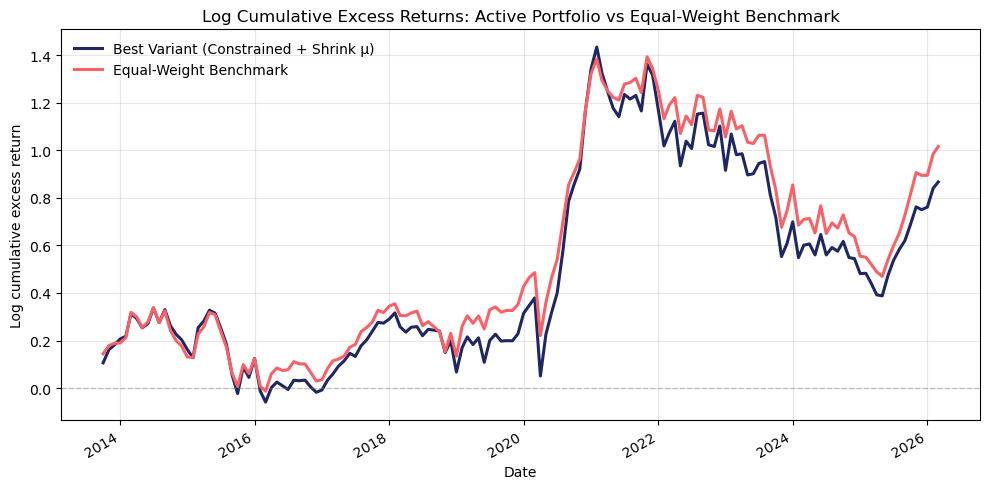

Saved chart -> C:\Users\swato\Downloads\QAM project\log_cumulative_excess_returns.png


In [ ]:
# 6. Log cumulative EXCESS return chart (saves PNG for the slide deck)
import matplotlib.pyplot as plt
import os

# Use month-end timestamps for a clean x-axis
plot_idx = best_excess.index.to_timestamp(how="end")

log_cum_best = np.log((1 + best_excess.values).cumprod())
log_cum_bench = np.log((1 + bench_excess.values).cumprod())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(plot_idx, log_cum_best, label="Best Variant (Constrained + Shrink μ)",
        linewidth=2.2, color="#1E2761")
ax.plot(plot_idx, log_cum_bench, label="Equal-Weight Benchmark",
        linewidth=2.2, color="#F96167")
ax.axhline(0, color="gray", linestyle="--", alpha=0.4, linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Log cumulative excess return")
ax.set_title("Log Cumulative Excess Returns: Active Portfolio vs Equal-Weight Benchmark")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()

png_path = "log_cumulative_excess_returns.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved chart -> {os.path.abspath(png_path)}")


In [ ]:
# 7. Dump everything to backtest_final_outputs.txt for the slide deck
out_path = "backtest_final_outputs.txt"
with open(out_path, "w") as f:
    f.write("=" * 60 + "\n")
    f.write("BACKTEST FINAL OUTPUTS\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"OOS period: {best_returns.index[0].strftime('%Y-%m')} to "
            f"{best_returns.index[-1].strftime('%Y-%m')} ({len(best_returns)} months)\n")
    f.write(f"Best variant: Constrained bounds + Shrink mu + Sample sigma + Monthly rebalance\n\n")

    f.write("--- Performance summary (with real Ken French RF) ---\n")
    f.write(metrics_df.to_string())
    f.write("\n\n")

    f.write("--- FF6 alpha regression: Best Variant ---\n")
    f.write(f"Monthly alpha   : {alpha_best_m:.4f}\n")
    f.write(f"Annualized alpha: {alpha_best_a:.4f}\n")
    f.write(f"t-stat (alpha)  : {t_best:.2f}\n")
    f.write(f"R-squared       : {model_best.rsquared:.4f}\n\n")

    f.write("--- FF6 alpha regression: Equal-Weight Benchmark ---\n")
    f.write(f"Monthly alpha   : {alpha_bench_m:.4f}\n")
    f.write(f"Annualized alpha: {alpha_bench_a:.4f}\n")
    f.write(f"t-stat (alpha)  : {t_bench:.2f}\n")
    f.write(f"R-squared       : {model_bench.rsquared:.4f}\n\n")

    f.write("--- Side-by-side coefficient table ---\n")
    f.write(ff6_table.to_string())
    f.write("\n")

print(f"Wrote {out_path}")
print()
print("=" * 60)
print("DONE. Two files were saved next to this notebook:")
print("  1. log_cumulative_excess_returns.png   (chart for the slide)")
print("  2. backtest_final_outputs.txt           (numbers for the slide)")
print("=" * 60)


Wrote backtest_final_outputs.txt

DONE. Two files were saved next to this notebook:
  1. log_cumulative_excess_returns.png   (chart for the slide)
  2. backtest_final_outputs.txt           (numbers for the slide)


In [139]:
import pandas_datareader.data as pdr

start = returns.index.min()

wti = pdr.DataReader("DCOILWTICO", "fred", start=start)
copper = pdr.DataReader("PCOPPUSDM", "fred", start=start)
dgs10 = pdr.DataReader("DGS10", "fred", start=start)
vix = pdr.DataReader("VIXCLS", "fred", start=start)

In [140]:
wti_ret = wti.pct_change()
copper_ret = copper.pct_change()
dgs10_chg = dgs10.diff()
vix_chg = vix.diff()

/tmp/ipykernel_17944/1317393417.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  wti_ret = wti.pct_change()


In [141]:
macro_df = pd.concat([
    wti_ret.rename(columns={"DCOILWTICO": "WTI_RET"}),
    copper_ret.rename(columns={"PCOPPUSDM": "COPPER_RET"}),
    dgs10_chg.rename(columns={"DGS10": "DGS10_CHG"}),
    vix_chg.rename(columns={"VIXCLS": "VIX_CHG"})
], axis=1)

# align with your returns index
returns = returns.join(macro_df, how="left")

In [142]:
for col in ["WTI_RET", "COPPER_RET", "DGS10_CHG", "VIX_CHG"]:
    returns[col + "_L1"] = returns[col].shift(1)

returns = returns.dropna()

In [143]:
print([col for col in returns.columns if "L1" in col])

['WTI_RET_L1', 'COPPER_RET_L1', 'DGS10_CHG_L1', 'VIX_CHG_L1']


In [170]:
# ============================================================
# MACRO / COMMODITY PREDICTOR EXTENSION
# Purpose:
# Add external predictors to improve expected return estimates (mu)
# without adding oil or commodity ETFs to the investable portfolio.
# ============================================================

# Rebuild returns from your original asset returns BEFORE macro merge
# If you saved it earlier, use that variable. Example:
# returns = asset_returns.copy()

asset_cols_clean = ["ICLN", "TAN", "FAN", "LIT", "QCLN", "SPY", "QQQ", "TLT"]

#returns_asset_only = returns[asset_cols_clean].copy()

#returns = returns_asset_only.copy()  # replace with your original clean ETF returns variable
# Rebuild clean monthly ETF returns from prices_monthly, not from returns
returns_base = prices_monthly[asset_cols_clean].pct_change().dropna()
returns_base.index = returns_base.index.to_period("M").to_timestamp("M")

# Convert daily macro data to month-end first
macro_monthly = pd.concat([
    wti.rename(columns={"DCOILWTICO": "WTI"}),
    copper.rename(columns={"PCOPPUSDM": "COPPER"}),
    dgs10.rename(columns={"DGS10": "DGS10"}),
    vix.rename(columns={"VIXCLS": "VIX"})
], axis=1).resample("M").last()

macro_monthly["WTI_RET"] = macro_monthly["WTI"].pct_change()
macro_monthly["COPPER_RET"] = macro_monthly["COPPER"].pct_change()
macro_monthly["DGS10_CHG"] = macro_monthly["DGS10"].diff()
macro_monthly["VIX_CHG"] = macro_monthly["VIX"].diff()

macro_monthly = macro_monthly[["WTI_RET", "COPPER_RET", "DGS10_CHG", "VIX_CHG"]]

for col in macro_monthly.columns:
    macro_monthly[col + "_L1"] = macro_monthly[col].shift(1)

macro_monthly = macro_monthly[[c for c in macro_monthly.columns if c.endswith("_L1")]]
macro_monthly.index = macro_monthly.index.to_period("M").to_timestamp("M")
returns.index = returns.index.to_period("M").to_timestamp("M")

# Join monthly macro predictors to monthly ETF returns
#returns_macro = returns[asset_cols_clean].join(macro_monthly, how="left")
#returns_macro = returns_macro.dropna()
returns_macro = returns_base.join(macro_monthly, how="left").dropna()

print("returns_macro rows:", len(returns_macro))
print(returns_macro.head())
print(returns_macro.tail())

returns_macro rows: 186
                ICLN       TAN       FAN       LIT      QCLN       SPY  \
Date                                                                     
2010-11-30 -0.123231 -0.185494 -0.105062  0.018602  0.012211  0.000000   
2010-12-31  0.075174  0.069869  0.093917  0.135967  0.042539  0.066852   
2011-01-31  0.041035  0.090411  0.022439 -0.040897  0.023752  0.023300   
2011-02-28  0.041844  0.031407  0.003817  0.033929  0.014277  0.034737   
2011-03-31  0.097206  0.071863  0.127376 -0.045676 -0.011730  0.000120   

                 QQQ       TLT  WTI_RET_L1  COPPER_RET_L1  DGS10_CHG_L1  \
Date                                                                      
2010-11-30 -0.001725 -0.016893    0.018762       0.072471          0.10   
2010-12-31  0.047571 -0.036990    0.032781       0.020345          0.18   
2011-01-31  0.028278 -0.030811    0.086305       0.082100          0.49   
2011-02-28  0.031607  0.016501   -0.004268       0.041555          0.12   
2011-03

/tmp/ipykernel_17944/3805108774.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ], axis=1).resample("M").last()
/tmp/ipykernel_17944/3805108774.py:30: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro_monthly["COPPER_RET"] = macro_monthly["COPPER"].pct_change()


In [171]:
for col in macro_predictors:
    print(col, col in returns.columns)

WTI_RET_L1 False
COPPER_RET_L1 False
DGS10_CHG_L1 False
VIX_CHG_L1 False


In [184]:
returns = returns_macro.copy()
benchmark_returns = returns[core].dot(np.repeat(1 / len(core), len(core)))

def run_backtest_macro(
    bounds_type="constrained",
    sigma_method="sample",
    rebalance_step=1,
    macro_weight=0.25,
    sample_weight=0.75,
    te_limit=None
):
    window = 36
    gamma = 5

    asset_cols_clean = ["ICLN", "TAN", "FAN", "LIT", "QCLN", "SPY", "QQQ", "TLT"]
    returns_opt = returns[asset_cols_clean].copy()
    portfolio_returns = []
    benchmark_oos = []
    weights_history = []

    core_len = len(core)
    benchmark_weights = np.repeat(1 / core_len, core_len)

    current_w = None

    for t in range(window, len(returns_opt) - 1):

        if current_w is None or (t - window) % rebalance_step == 0:

            train_assets = returns_opt.iloc[t-window:t]
            train_predictors = returns[macro_predictors].iloc[t-window:t]

            # -----------------------------
            # Build normalized predictors
            # -----------------------------
            X_train = train_predictors.values
            X_train = (X_train - X_train.mean(axis=0)) / (X_train.std(axis=0) + 1e-8)
            X_train = np.column_stack([np.ones(len(X_train)), X_train])

            x_next = returns[macro_predictors].iloc[t].values
            x_next = (x_next - train_predictors.mean().values) / (train_predictors.std().values + 1e-8)
            x_next = np.r_[1, x_next]

            # -----------------------------
            # Estimate macro-based mu
            # -----------------------------
            mu_macro = []

            for asset in asset_cols_clean:
                y = train_assets[asset].values

                # Guard against bad inputs
                if np.isnan(X_train).any() or np.isnan(y).any():
                    mu_macro.append(0)
                    continue

                try:
                    beta = np.linalg.lstsq(X_train, y, rcond=None)[0]
                    pred_mu = x_next @ beta

                    # Catch invalid outputs
                    if np.isnan(pred_mu) or np.isinf(pred_mu):
                        mu_macro.append(0)
                    else:
                        mu_macro.append(pred_mu)

                except:
                    mu_macro.append(0)

            # -----------------------------
            # Combine forecasts
            # -----------------------------
            mu_macro = np.array(mu_macro)
            mu_macro = np.nan_to_num(mu_macro)

            mu_sample = train_assets.mean().values
            mu_sample = np.nan_to_num(mu_sample)

            mu = sample_weight * mu_sample + macro_weight * mu_macro
            mu = np.nan_to_num(mu)

            # X_train = train_predictors.values
            # X_train = (X_train - X_train.mean(axis=0)) / (X_train.std(axis=0) + 1e-8)
            # X_train = np.column_stack([np.ones(len(X_train)), X_train])

            # x_next = returns[macro_predictors].iloc[t].values
            # x_next = (x_next - train_predictors.mean().values) / (train_predictors.std().values + 1e-8)
            # x_next = np.r_[1, x_next]

            # mu_macro = []

            # for asset in asset_cols_clean:
            #     y = train_assets[asset].values
            #     # beta = np.linalg.lstsq(X_train, y, rcond=None)[0]
            #     # pred_mu = x_next @ beta
            #     # mu_macro.append(pred_mu)
            #     # Guard against bad inputs
            #     if np.isnan(X_train).any() or np.isnan(y).any():
            #         mu_macro.append(0)
            #         continue

            #     try:
            #         beta = np.linalg.lstsq(X_train, y, rcond=None)[0]
            #         pred_mu = x_next @ beta

            #    # Catch exploding or invalid predictions
            #     if np.isnan(pred_mu) or np.isinf(pred_mu):
            #        mu_macro.append(0)
            #     else:
            #         mu_macro.append(pred_mu)

            #         except:
            #             mu_macro.append(0)

            # mu_macro = np.array(mu_macro)
            # mu_sample = train_assets.mean().values
            # mu_macro = np.nan_to_num(mu_macro)
            # mu_sample = np.nan_to_num(mu_sample)

            # mu = sample_weight * mu_sample + macro_weight * mu_macro
            # mu = np.nan_to_num(mu)

            # # Forecast combination
            # mu = sample_weight * mu_sample + macro_weight * mu_macro

            if sigma_method == "sample":
                Sigma = train_assets.cov().values
            elif sigma_method == "lw":
                Sigma = LedoitWolf().fit(train_assets.values).covariance_
            else:
                raise ValueError(f"Unknown sigma_method: {sigma_method}")

            x = optimize_active(
                mu,
                Sigma,
                gamma=gamma,
                bounds_type=bounds_type
            )



            if x is None:
                x = np.zeros(len(asset_cols_clean))

            current_w = get_portfolio_weights(x, benchmark_weights, core_len)

        next_ret = returns_opt.iloc[t+1].values

        portfolio_returns.append(current_w @ next_ret)
        benchmark_oos.append(benchmark_returns.iloc[t+1])
        weights_history.append(current_w)

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=returns.index[window+1:],
        name="Macro Predictor Portfolio"
    )

    benchmark_oos = pd.Series(
        benchmark_oos,
        index=returns.index[window+1:],
        name="Equal-Weight Benchmark"
    )

    weights_history = pd.DataFrame(
        weights_history,
        index=returns.index[window+1:],
        columns=asset_cols_clean
    )

    return portfolio_returns, benchmark_oos, weights_history

In [185]:
macro_returns, macro_bench, macro_weights = run_backtest_macro(
    bounds_type="constrained",
    sigma_method="lw",
    rebalance_step=1,
    macro_weight=0.25,
    sample_weight=0.75,
    te_limit=0.05 / np.sqrt(12)
)

In [186]:
print("returns_macro shape:", returns_macro.shape)
print(returns_macro.columns)

returns_macro shape: (186, 12)
Index(['ICLN', 'TAN', 'FAN', 'LIT', 'QCLN', 'SPY', 'QQQ', 'TLT', 'WTI_RET_L1',
       'COPPER_RET_L1', 'DGS10_CHG_L1', 'VIX_CHG_L1'],
      dtype='object')


In [187]:
print("macro_returns length:", len(macro_returns))
print("macro_returns NaNs:", macro_returns.isna().sum())
print("macro_returns head:")
print(macro_returns.head())

print("\nmacro_weights shape:", macro_weights.shape)
print("macro_weights NaNs:")
print(macro_weights.isna().sum())

print("\nasset columns available:")
print(returns[asset_cols_clean].isna().sum())

print("\nmacro predictors available:")
print(returns[macro_predictors].isna().sum())

macro_returns length: 149
macro_returns NaNs: 0
macro_returns head:
Date
2013-12-31    0.024168
2014-01-31    0.015490
2014-02-28    0.104651
2014-03-31   -0.010760
2014-04-30   -0.031954
Freq: ME, Name: Macro Predictor Portfolio, dtype: float64

macro_weights shape: (149, 8)
macro_weights NaNs:
ICLN    0
TAN     0
FAN     0
LIT     0
QCLN    0
SPY     0
QQQ     0
TLT     0
dtype: int64

asset columns available:
ICLN    0
TAN     0
FAN     0
LIT     0
QCLN    0
SPY     0
QQQ     0
TLT     0
dtype: int64

macro predictors available:
WTI_RET_L1       0
COPPER_RET_L1    0
DGS10_CHG_L1     0
VIX_CHG_L1       0
dtype: int64


In [188]:
macro_comparison = pd.concat([
    performance_summary(mu_shrink_returns),
    performance_summary(macro_returns),
    performance_summary(macro_bench)
], axis=1)

macro_comparison.columns = [
    "Best Prior: Shrink μ",
    "Macro Predictor Extension",
    "Equal-Weight Benchmark"
]

macro_comparison

,Best Prior: Shrink μ,Macro Predictor Extension,Equal-Weight Benchmark
Annualized Return,0.137129,0.101295,0.127020
Annualized Volatility,0.288460,0.285680,0.255279
Sharpe Ratio,0.475382,0.354573,0.497573
Max Drawdown,-0.601961,-0.629027,-0.547463


In [189]:
print("returns rows:", len(returns))
print("benchmark_returns rows:", len(benchmark_returns))
print("returns date range:", returns.index.min(), returns.index.max())
print("benchmark date range:", benchmark_returns.index.min(), benchmark_returns.index.max())

returns rows: 186
benchmark_returns rows: 186
returns date range: 2010-11-30 00:00:00 2026-04-30 00:00:00
benchmark date range: 2010-11-30 00:00:00 2026-04-30 00:00:00


In [190]:
macro_comparison = pd.concat([
    performance_summary(mu_shrink_returns),
    performance_summary(macro_returns),
    performance_summary(benchmark_oos)
], axis=1)

macro_comparison.columns = [
    "Best Prior: Shrink μ",
    "Macro Predictor Extension",
    "Equal-Weight Benchmark"
]

macro_comparison

,Best Prior: Shrink μ,Macro Predictor Extension,Equal-Weight Benchmark
Annualized Return,0.137129,0.101295,0.127020
Annualized Volatility,0.288460,0.285680,0.255279
Sharpe Ratio,0.475382,0.354573,0.497573
Max Drawdown,-0.601961,-0.629027,-0.547463


In [191]:
weights_summary(macro_weights)

,Average Weight (%),Min Weight (%),Max Weight (%)
ICLN,12.27,5.0,35.0
TAN,19.52,5.0,35.0
FAN,20.71,5.0,35.0
LIT,18.54,5.0,35.0
QCLN,23.24,5.0,35.0
SPY,5.34,-15.0,15.0
QQQ,9.84,-15.0,15.0
TLT,-9.46,-15.0,15.0


In [193]:
core_only = ["ICLN", "TAN", "FAN", "LIT", "QCLN"]

In [206]:
def run_backtest_core_only(bounds_type="constrained",
                          mu_method="shrink",
                          sigma_method="lw",
                          rebalance_step=1):

    window = 36
    gamma = 5

    # --- Core-only assets (no SPY, QQQ, TLT) ---
    asset_cols_clean = ["ICLN", "TAN", "FAN", "LIT", "QCLN"]
    returns_opt = returns[asset_cols_clean].copy()

    portfolio_returns = []
    benchmark_oos = []
    weights_history = []

    current_w = None

    for t in range(window, len(returns_opt) - 1):

        if current_w is None or (t - window) % rebalance_step == 0:

            train = returns_opt.iloc[t-window:t]

            # --- Expected return estimation ---
            if mu_method == "sample":
                mu = train.mean().values

            elif mu_method == "shrink":
                mu = 0.5 * train.mean().values

            elif mu_method == "strong_shrink":
                mu = 0.25 * train.mean().values

            elif mu_method == "combo":
                mu_sample = train.mean().values
                mu_shrink = 0.5 * mu_sample
                mu = 0.25 * mu_sample + 0.75 * mu_shrink

            elif mu_method == "combo_strong":
                mu_sample = train.mean().values
                mu_shrink = 0.25 * mu_sample
                mu = 0.2 * mu_sample + 0.8 * mu_shrink

            else:
                raise ValueError(f"Unknown mu_method: {mu_method}")

            # --- Covariance estimation ---
            if sigma_method == "sample":
                Sigma = train.cov().values

            elif sigma_method == "lw":
                from sklearn.covariance import LedoitWolf
                Sigma = LedoitWolf().fit(train.values).covariance_

            else:
                raise ValueError(f"Unknown sigma_method: {sigma_method}")

            # --- Clean numerical issues ---
            mu = np.nan_to_num(mu)
            Sigma = np.nan_to_num(Sigma)

            # --- Optimize ---
            from scipy.optimize import minimize

            n = len(asset_cols_clean)

            def objective(w):
                return -(w @ mu - 0.5 * gamma * w @ Sigma @ w)

            constraints = ({
                "type": "eq",
                "fun": lambda w: np.sum(w) - 1
            })

            bounds = [(0.05, 0.35)] * n
            x0 = np.repeat(1 / n, n)

            result = minimize(
                objective,
                x0,
                method="SLSQP",
                bounds=bounds,
                constraints=constraints
            )

            if result.success:
                current_w = result.x
            else:
                print("Core-only optimization failed:", result.message)
                current_w = x0

            # if x is None:
            #     x = np.zeros(len(asset_cols_clean))

            # current_w = x

        # --- Out-of-sample return ---
        next_ret = returns_opt.iloc[t+1].values
        portfolio_returns.append(current_w @ next_ret)

        # --- Equal-weight benchmark (core only) ---
        benchmark_oos.append(returns_opt.iloc[t+1].mean())

        weights_history.append(current_w)

    # --- Convert to series/dataframe ---
    portfolio_returns = pd.Series(
        portfolio_returns,
        index=returns_opt.index[window+1:],
        name="Core-Only Active"
    )

    benchmark_oos = pd.Series(
        benchmark_oos,
        index=returns_opt.index[window+1:],
        name="Core-Only Benchmark"
    )

    weights_history = pd.DataFrame(
        weights_history,
        index=returns_opt.index[window+1:],
        columns=asset_cols_clean
    )

    return portfolio_returns, benchmark_oos, weights_history

In [207]:
core_returns, core_bench, core_weights = run_backtest_core_only(
    bounds_type="constrained",
    mu_method="shrink",
    sigma_method="lw",
    rebalance_step=1
)

In [208]:
core_comparison = pd.concat([
    performance_summary(core_returns),
    performance_summary(core_bench)
], axis=1)

core_comparison.columns = [
    "Core-Only Active",
    "Core-Only Equal Weight"
]

core_comparison

,Core-Only Active,Core-Only Equal Weight
Annualized Return,0.121603,0.127020
Annualized Volatility,0.234488,0.255279
Sharpe Ratio,0.518591,0.497573
Max Drawdown,-0.503696,-0.547463


In [209]:
run_backtest_core_only(mu_method="shrink")
run_backtest_core_only(mu_method="strong_shrink")
run_backtest_core_only(mu_method="combo")
run_backtest_core_only(mu_method="combo_strong")

(Date
 2013-12-31    0.022634
 2014-01-31    0.012970
 2014-02-28    0.098671
 2014-03-31   -0.015052
 2014-04-30   -0.034394
                 ...   
 2025-12-31    0.009422
 2026-01-31    0.096024
 2026-02-28    0.054404
 2026-03-31   -0.000743
 2026-04-30    0.135526
 Freq: ME, Name: Core-Only Active, Length: 149, dtype: float64,
 Date
 2013-12-31    0.001868
 2014-01-31    0.021934
 2014-02-28    0.112898
 2014-03-31   -0.018943
 2014-04-30   -0.043796
                 ...   
 2025-12-31    0.003864
 2026-01-31    0.096867
 2026-02-28    0.034492
 2026-03-31   -0.005215
 2026-04-30    0.142344
 Freq: ME, Name: Core-Only Benchmark, Length: 149, dtype: float64,
                 ICLN   TAN   FAN       LIT      QCLN
 Date                                                
 2013-12-31  0.050000  0.05  0.35  0.200019  0.349981
 2014-01-31  0.050251  0.05  0.35  0.199749  0.350000
 2014-02-28  0.050000  0.05  0.35  0.200000  0.350000
 2014-03-31  0.050000  0.05  0.35  0.200000  0.350000
 2014

In [210]:
ret_shrink, _, _ = run_backtest_core_only(mu_method="shrink")
ret_strong, _, _ = run_backtest_core_only(mu_method="strong_shrink")
ret_combo, _, _ = run_backtest_core_only(mu_method="combo")
ret_combo_strong, bench_core, _ = run_backtest_core_only(mu_method="combo_strong")

In [211]:
comparison = pd.concat([
    performance_summary(ret_shrink),
    performance_summary(ret_strong),
    performance_summary(ret_combo),
    performance_summary(ret_combo_strong),
    performance_summary(bench_core)
], axis=1)

comparison.columns = [
    "Shrink μ",
    "Strong Shrink μ",
    "Combo",
    "Combo Strong",
    "Equal Weight"
]

comparison

,Shrink μ,Strong Shrink μ,Combo,Combo Strong,Equal Weight
Annualized Return,0.121603,0.121802,0.122939,0.119025,0.127020
Annualized Volatility,0.234488,0.229267,0.239282,0.232053,0.255279
Sharpe Ratio,0.518591,0.531264,0.513785,0.512922,0.497573
Max Drawdown,-0.503696,-0.472577,-0.529291,-0.503596,-0.547463


In [212]:
ret_strong, bench_core, weights_strong = run_backtest_core_only(
    mu_method="strong_shrink",
    sigma_method="lw",
    rebalance_step=1
)

In [213]:
weights_summary(weights_strong)

,Average Weight (%),Min Weight (%),Max Weight (%)
ICLN,18.90,5.0,35.0
TAN,5.00,5.0,5.0
FAN,33.53,19.4,35.0
LIT,24.14,5.0,35.0
QCLN,18.43,5.0,35.0


In [214]:
weights_strong.tail(12)

,ICLN,TAN,FAN,LIT,QCLN
Date,,,,,
2025-05-31,0.267126,0.05,0.35,0.282874,0.05
2025-06-30,0.266377,0.05,0.35,0.283623,0.05
2025-07-31,0.260103,0.05,0.35,0.289897,0.05
2025-08-31,0.264298,0.05,0.35,0.285702,0.05
2025-09-30,0.281976,0.05,0.35,0.268024,0.05
2025-10-31,0.285463,0.05,0.35,0.264537,0.05
2025-11-30,0.305178,0.05,0.35,0.244822,0.05
2025-12-31,0.305455,0.05,0.35,0.244545,0.05
2026-01-31,0.306527,0.05,0.35,0.243473,0.05
